In [1]:
import sys
from pathlib import Path

working_path = Path.cwd().resolve()
src_dir = next(path / 'src' for path in (working_path, *working_path.parents) if (path / 'src').is_dir())
sys.path.insert(0, str(src_dir))
main_dir = src_dir.parent
from imports import *

figure_7_dir = main_dir / 'notebooks' / 'Figure_7'
figures_folder = figure_7_dir / 'figures'
raw_data_folder = figure_7_dir / 'raw_data'
figures_folder.mkdir(parents=True, exist_ok=True)
raw_data_folder.mkdir(parents=True, exist_ok=True)


In [2]:
path_main_folder = Path('/Volumes/LaCie/UTag_paper_data/ACF')
if not path_main_folder.is_dir():
    raise FileNotFoundError(f'Required LaCie ACF source is unavailable: {path_main_folder}')
results_folder = figures_folder
print(f'Figure 7C–E source: {path_main_folder}')


Figure 7C–E source: /Volumes/LaCie/UTag_paper_data/ACF


In [3]:
# Verified against the microscope metadata.
pixel_xy_um = 0.12989318982387477

In [4]:
DATASET_FOLDERS = {
    'utag': 'UTag_ACF',
    'utag_c_free': 'UTag_CF_ACF',
    'suntag': 'SunTag_ACF',
    'alfatag': 'AlfaTag_ACF',
}


def dataset_folder(dataset):
    try:
        return path_main_folder / DATASET_FOLDERS[dataset]
    except KeyError as error:
        raise ValueError(f'Unknown dataset: {dataset}') from error


In [5]:
def load_tracking_data(root_folder: Path, selected_field: str):
    result_folders = sorted(
        (folder for folder in root_folder.iterdir() if folder.is_dir() and folder.name.startswith('results_')),
        key=lambda folder: folder.name,
    )
    extracted_values = []
    for folder in result_folders:
        tracking_files = sorted(
            (
                file for file in folder.iterdir()
                if file.is_file()
                and file.name.startswith('tracking_')
                and file.suffix.lower() == '.csv'
                and not file.name.startswith('._')
            ),
            key=lambda file: file.name,
        )
        if len(tracking_files) != 1:
            raise ValueError(
                f'Expected exactly one real tracking CSV in {folder}; found {len(tracking_files)}.'
            )
        values = pd.read_csv(tracking_files[0])[selected_field].dropna().to_numpy()
        extracted_values.append(values)
    return np.array(extracted_values, dtype=object)


In [6]:
def extract_data(selected_field, datasets):
    return [load_tracking_data(dataset_folder(dataset), selected_field) for dataset in datasets]


In [7]:
def plot_repetition_means_box_swarm_plot(
    conditions_data,
    condition_labels,
    x_label="Condition",
    y_label="Mean Value",
    title="",
    figsize=(6, 4),
    tick_size=16,
    swarm_color="black",
    y_lim=None,
    show_stats=False,
    save_dir=None,
    plot_name = 'temp',
    max_percentile_significance=99.5,
    calculate_stats=True,
    x_tick_rotation=0,
):
    """Plot one mean value per imaged cell and return the plotted table."""

    sns.set_style("ticks")
    
    mean_values = []
    condition_list = []
    for cond_idx, repetitions in enumerate(conditions_data):
        for rep in repetitions:
            rep_mean = np.nanmean(rep)
            mean_values.append(rep_mean)
            condition_list.append(condition_labels[cond_idx])
    
    df = pd.DataFrame({
        "Mean": mean_values,
        "Condition": condition_list
    })
    
    plt.figure(figsize=figsize, facecolor='white')
    ax = sns.boxplot(
        x="Condition",
        y="Mean",
        data=df,
        order=condition_labels,
        showfliers=False,
        boxprops={'facecolor': 'white', 'edgecolor': 'black'},
        medianprops={'color': 'red'},
        whiskerprops={'color': 'black'},
        capprops={'color': 'black'},
        linewidth=1.5,
        whis=[5, 95],
        width=0.5,
    )
    ax.set_facecolor('white')
    
    sns.swarmplot(
        x="Condition",
        y="Mean",
        data=df,
        order=condition_labels,
        color=swarm_color,
        size=5,
    )
    
    ax.set_xlabel(x_label, fontsize=tick_size + 4, fontname="Arial", color='black')
    ax.set_ylabel(y_label, fontsize=tick_size + 4, fontname="Arial", color='black')
    ax.set_title(title, fontsize=tick_size + 4, fontname="Arial", color='black')
    
    ax.tick_params(axis='x', labelsize=tick_size , colors='black')
    ax.tick_params(axis='y', labelsize=tick_size, colors='black')
    
    for label in ax.get_xticklabels():
        label.set_rotation(x_tick_rotation)
        label.set_fontname("Arial")
        label.set_ha('right' if x_tick_rotation > 0 else 'center')
    for label in ax.get_yticklabels():
        label.set_fontname("Arial")
    
    global_max = np.nanpercentile(df["Mean"].to_numpy(), max_percentile_significance)
    global_min = np.nanmin(df["Mean"].to_numpy())
    global_range = global_max - global_min if (global_max - global_min) != 0 else 1
    offset = 0.15 * global_range
    bar_height = 0.02 * global_range
    k = 0
    p_values = {}
    

    print(f'\n{plot_name} cell means')
    for cond in condition_labels:
        group_data = df[df["Condition"] == cond]["Mean"]
        group_mean = np.nanmean(group_data)
        group_std = np.nanstd(group_data)
        n_samples = len(group_data)
        group_sem = group_std / np.sqrt(n_samples) if n_samples > 1 else 0
        print(f"  {cond}: {group_mean:.3f} ± {group_sem:.4f} (n={n_samples})")

    if calculate_stats and len(condition_labels) > 1:
        print(f'{plot_name} pairwise Mann–Whitney tests')
        num_conditions = len(condition_labels)        
        for i in range(num_conditions - 1):
            for j in range(i + 1, num_conditions):
                group1 = df[df["Condition"] == condition_labels[i]]["Mean"]
                group2 = df[df["Condition"] == condition_labels[j]]["Mean"]
                group1 = group1[~np.isnan(group1)]
                group2 = group2[~np.isnan(group2)]
                if len(group1) > 0 and len(group2) > 0:
                    stat, p = mannwhitneyu(group1, group2)
                    comparison_key = f"{condition_labels[i]} vs {condition_labels[j]}"
                    p_values[comparison_key] = p
                else:
                    p = np.nan
                    comparison_key = f"{condition_labels[i]} vs {condition_labels[j]}"
                    p_values[comparison_key] = p
                if p < 0.0001:
                    sig = '****'
                elif p < 0.001:
                    sig = '***'
                elif p < 0.01:
                    sig = '**'
                elif p < 0.05:
                    sig = '*'
                else:
                    sig = 'ns'
                print(f"  {condition_labels[i]} vs {condition_labels[j]}: p = {p:.6f} ({sig})")
                if show_stats:
                    if sig != 'ns':
                        x1 = i
                        x2 = j
                        y_line = global_max + offset * (k + 1)
                        ax.plot([x1, x1, x2, x2],
                                [y_line, y_line + bar_height, y_line + bar_height, y_line],
                                lw=1.5, c='k')
                        ax.text((x1 + x2) * 0.5, y_line + bar_height,
                                sig, ha='center', va='bottom',
                                color='k', fontsize=tick_size-4, fontname="Arial")
                        k += 1
    
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
        spine.set_color('black')
    
    ax.tick_params(axis='both', which='major', width=2.0, length=6, colors='black')

    if y_lim is not None and not show_stats:
        ax.set_ylim(y_lim)
    elif show_stats and k > 0:
        highest_bar = global_max + offset * k + bar_height
        padding = 0.1 * (highest_bar - global_min)
        ax.set_ylim(global_min, highest_bar + padding)
    elif y_lim is not None:
        ax.set_ylim(y_lim)
    
    if save_dir is not None:
        plt.savefig(save_dir.joinpath(plot_name+".png"), dpi=600, bbox_inches='tight')
        plt.savefig(
            save_dir.joinpath(plot_name+".svg"), dpi=600, bbox_inches='tight', metadata={'Date': None}
        )
    
    plt.show()
    return ax, p_values, df


Figure_7C_spot_intensity cell means
  UTag: 2227.161 ± 229.3464 (n=19)
  UTag($\Delta$Cys): 2090.201 ± 264.7249 (n=14)
  SunTag: 2170.292 ± 228.0485 (n=16)
  ALFA-tag: 2360.443 ± 238.7776 (n=11)
Figure_7C_spot_intensity pairwise Mann–Whitney tests
  UTag vs UTag($\Delta$Cys): p = 0.812836 (ns)
  UTag vs SunTag: p = 0.907735 (ns)
  UTag vs ALFA-tag: p = 0.763220 (ns)
  UTag($\Delta$Cys) vs SunTag: p = 0.819150 (ns)
  UTag($\Delta$Cys) vs ALFA-tag: p = 0.366372 (ns)
  SunTag vs ALFA-tag: p = 0.474286 (ns)


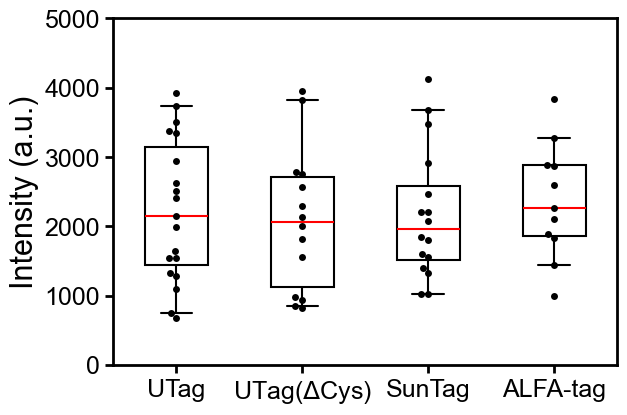

In [8]:

list_datasets = [ 'utag', 'utag_c_free','suntag', 'alfatag']
list_constructs_names = ['UTag', r'UTag($\Delta$Cys)','SunTag', 'ALFA-tag']
canonical_condition_labels = ['UTag', 'UTag_DeltaCys', 'SunTag', 'ALFA_tag']
condition_label_to_csv = dict(zip(list_constructs_names, canonical_condition_labels))

def export_box_swarm_source_data(plot_dataframe, value_column, filename):
    export_dataframe = plot_dataframe.rename(columns={'Condition': 'condition', 'Mean': value_column}).copy()
    export_dataframe['condition'] = export_dataframe['condition'].map(condition_label_to_csv)
    if export_dataframe['condition'].isna().any():
        raise ValueError('A plotted condition does not have an approved publication label.')
    export_dataframe[['condition', value_column]].to_csv(raw_data_folder / filename, index=False)
    return export_dataframe[['condition', value_column]]

figsize=(6.5, 4.5)
tick_size = 18
show_stats = True

selected_field = 'spot_int_ch_0'  
list_extracted_data = extract_data(selected_field, list_datasets)
_, _, figure_7c_plot_dataframe = plot_repetition_means_box_swarm_plot(
    list_extracted_data,
    list_constructs_names,
    x_label="",
    y_label="Intensity (a.u.)",
    title="",
    figsize=figsize,
    tick_size=tick_size,
    swarm_color="black",
    y_lim=(0, 5000),
    show_stats=show_stats,
    max_percentile_significance = 99.0,
    save_dir=results_folder,
    plot_name= "Figure_7C_spot_intensity",
    x_tick_rotation=0,
)
figure_7c_source_data = export_box_swarm_source_data(
    figure_7c_plot_dataframe,
    'mean_spot_intensity_au',
    'Figure_7C_spot_intensity_individual_cell_means.csv',
)


Figure_7D_spot_SNR cell means
  UTag: 2.765 ± 0.1113 (n=19)
  UTag($\Delta$Cys): 2.640 ± 0.1617 (n=14)
  SunTag: 2.773 ± 0.2472 (n=16)
  ALFA-tag: 3.284 ± 0.3622 (n=11)
Figure_7D_spot_SNR pairwise Mann–Whitney tests
  UTag vs UTag($\Delta$Cys): p = 0.477515 (ns)
  UTag vs SunTag: p = 0.881546 (ns)
  UTag vs ALFA-tag: p = 0.413533 (ns)
  UTag($\Delta$Cys) vs SunTag: p = 0.692902 (ns)
  UTag($\Delta$Cys) vs ALFA-tag: p = 0.261748 (ns)
  SunTag vs ALFA-tag: p = 0.288714 (ns)


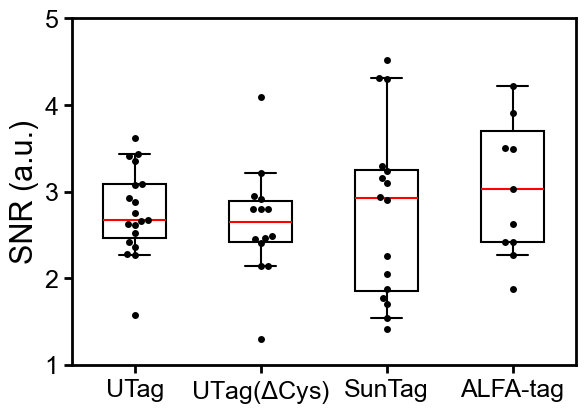

In [9]:
selected_field = 'snr_ch_0'  # psf_sigma_ch_0, psf_amplitude_ch_0, snr_ch_0, total_spot_int_ch_0, spot_int_ch_0
list_extracted_data = extract_data(selected_field, list_datasets)
_, _, figure_7d_plot_dataframe = plot_repetition_means_box_swarm_plot(
    list_extracted_data,
    list_constructs_names,
    x_label="",
    y_label="SNR (a.u.)",
    title="",
    figsize=figsize,
    tick_size=tick_size,
    swarm_color="black",
    y_lim=(1, 5),
    show_stats=show_stats,
    max_percentile_significance = 99.0,
    save_dir=results_folder,
    plot_name= "Figure_7D_spot_SNR",
    x_tick_rotation=0,
)
figure_7d_source_data = export_box_swarm_source_data(
    figure_7d_plot_dataframe,
    'mean_spot_snr_au',
    'Figure_7D_spot_SNR_individual_cell_means.csv',
)


Figure_7E_spot_size_um cell means
  UTag: 0.325 ± 0.0047 (n=19)
  UTag($\Delta$Cys): 0.336 ± 0.0101 (n=14)
  SunTag: 0.363 ± 0.0118 (n=16)
  ALFA-tag: 0.324 ± 0.0059 (n=11)
Figure_7E_spot_size_um pairwise Mann–Whitney tests
  UTag vs UTag($\Delta$Cys): p = 0.927441 (ns)
  UTag vs SunTag: p = 0.002729 (**)
  UTag vs ALFA-tag: p = 0.575838 (ns)
  UTag($\Delta$Cys) vs SunTag: p = 0.039615 (*)
  UTag($\Delta$Cys) vs ALFA-tag: p = 0.848050 (ns)
  SunTag vs ALFA-tag: p = 0.008290 (**)


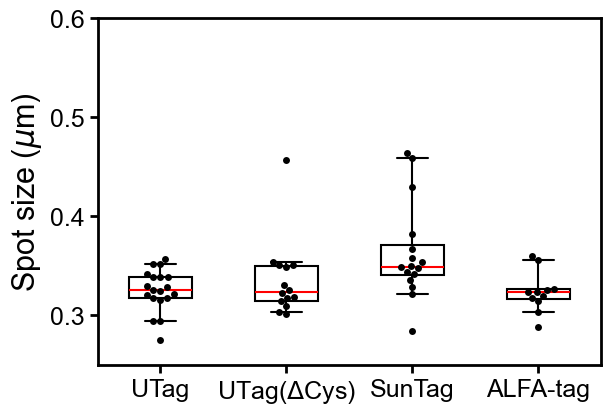

In [10]:
selected_field = 'spot_size_ch_0'  
list_extracted_data = extract_data(selected_field, list_datasets)
list_extracted_data_um = [data * pixel_xy_um for data in list_extracted_data]
_, _, figure_7e_plot_dataframe = plot_repetition_means_box_swarm_plot(
    list_extracted_data_um,
    list_constructs_names,
    x_label="",
    y_label=r"Spot size ($\mu$m)",
    title="",
    figsize=figsize,
    tick_size=tick_size,
    swarm_color="black",
    y_lim=(0.25, 0.6),
    show_stats=False,
    max_percentile_significance = 99.9,
    save_dir=results_folder,
    plot_name= "Figure_7E_spot_size_um",
    x_tick_rotation=0,
)
figure_7e_source_data = export_box_swarm_source_data(
    figure_7e_plot_dataframe,
    'mean_spot_size_um',
    'Figure_7E_spot_size_individual_cell_means.csv',
)